# NEXATEL CUSTOMER CHURN ANALYTICS
## PHASE 2 — EXPLORATORY DATA ANALYSIS

### OBJECTIVE

THE OBJECTIVE OF THIS PHASE IS TO EXPLORE CUSTOMER CHURN PATTERNS AND IDENTIFY RELATIONSHIPS BETWEEN CHURN AND CUSTOMER CHARACTERISTICS, USAGE BEHAVIOUR, BILLING, NETWORK QUALITY, COMPLAINTS AND RETENTION ACTIVITIES.

THIS PHASE COVERS THE 10 EDA ANALYSES SPECIFIED IN THE PROJECT REQUIREMENTS. EACH ANALYSIS WILL INCLUDE A VISUALIZATION AND A SHORT BUSINESS OBSERVATION.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

In [2]:
cleaned_data_path = Path("../data/cleaned")
charts_path = Path("../outputs/charts")

charts_path.mkdir(parents=True, exist_ok=True)

FOR PHASE 2, WE DON'T NEED TO IMMEDIATELY LOAD ALL 24 TABLES. WE'LL LOAD THE TABLES AS THEY'RE REQUIRED BY THE INDIVIDUAL ANALYSES. THIS KEEPS THE NOTEBOOK ORGANIZED AND MAKES IT CLEAR WHICH TABLES SUPPORT EACH ANALYSIS.

In [3]:
customers = pd.read_csv(cleaned_data_path / "customers.csv")
subscriptions = pd.read_csv(cleaned_data_path / "subscriptions.csv")
plans = pd.read_csv(cleaned_data_path / "plans.csv")

In [4]:
print("Customers:", customers.shape)
print("Subscriptions:", subscriptions.shape)
print("Plans:", plans.shape)

Customers: (19000, 25)
Subscriptions: (20523, 8)
Plans: (25, 10)


In [5]:
print("Customers:")
print(customers.columns.tolist())

print("\nSubscriptions:")
print(subscriptions.columns.tolist())

print("\nPlans:")
print(plans.columns.tolist())

Customers:
['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'age', 'email', 'phone_number', 'address', 'city_id', 'city_name', 'state_id', 'pin_code', 'city_tier', 'region_id', 'occupation', 'annual_income_inr', 'customer_segment', 'product_line', 'plan_id', 'acquisition_channel', 'acquisition_date', 'tenure_months', 'customer_status', 'churn_date']

Subscriptions:
['subscription_id', 'customer_id', 'plan_id', 'start_date', 'end_date', 'billing_cycle', 'monthly_charge_inr', 'subscription_status']

Plans:
['plan_id', 'plan_name', 'product_line', 'billing_cycle', 'monthly_charge', 'data_quota_gb', 'voice_minutes', 'sms_count', 'segment', 'is_active']


## Chart 1 — Overall Churn Rate

### For this chart, the important customer columns are:
- customer_id → identifies each customer
- customer_status → tells us whether the customer is active/churned
- churn_date → provides additional churn information

STEP 1: CHECK CUSTOMER STATUS VALUES

In [6]:
customers["customer_status"].value_counts(dropna=False)

customer_status
Active     15494
Churned     3506
Name: count, dtype: int64

STEP 2: CALCULATE THE OVERALL CHURN RATE

In [7]:
total_customers = customers["customer_id"].nunique()
churned_customers = (customers["customer_status"] == "Churned").sum()

churn_rate = (churned_customers / total_customers) * 100

print(f"Total customers: {total_customers:,}")
print(f"Churned customers: {churned_customers:,}")
print(f"Overall churn rate: {churn_rate:.2f}%")

Total customers: 19,000
Churned customers: 3,506
Overall churn rate: 18.45%


STEP 3: CREATE THE OVERALL CHURN RATE CHART

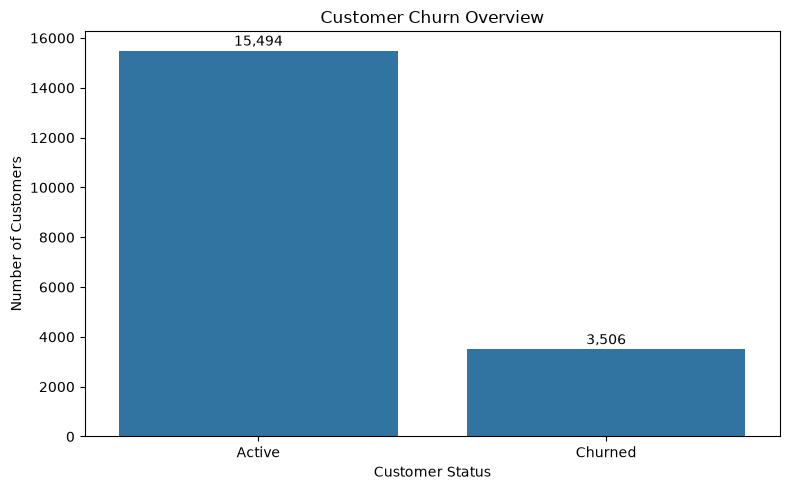

In [8]:
status_counts = customers["customer_status"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Customer Churn Overview")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for i, value in enumerate(status_counts.values):
    plt.text(i, value + 200, f"{value:,}", ha="center")

plt.tight_layout()

plt.savefig(charts_path / "01_overall_churn_rate.png", dpi=300)
plt.show()

### Business Observation For Chart 1

NexaTel has an overall customer churn rate of 18.45%, with 3,506 out of 19,000 customers classified as churned. This indicates that nearly one in five customers has churned, highlighting customer retention as an important area for further analysis.

## Chart 2 — Churn by Billing Cycle (Monthly vs Annual).

STEP 1: CHECK THE BILLING-CYCLE VALUES

In [9]:
subscriptions["billing_cycle"].value_counts(dropna=False)

billing_cycle
Monthly    15107
Annual      5416
Name: count, dtype: int64

BEFORE CALCULATING CHURN, THERE'S ONE IMPORTANT DATA-MODEL POINT: A CUSTOMER CAN POTENTIALLY HAVE MORE THAN ONE SUBSCRIPTION RECORD, SO WE SHOULDN'T BLINDLY MERGE ALL SUBSCRIPTION ROWS WITH CUSTOMERS AND CALL THAT A CUSTOMER CHURN RATE.

STEP 2: CHECK WHETHER CUSTOMERS HAVE MULTIPLE SUBSCRIPTION RECORDS

In [10]:
subscription_counts = subscriptions["customer_id"].value_counts()

print("Customers with more than one subscription:",
      (subscription_counts > 1).sum())

print("Maximum subscriptions for one customer:",
      subscription_counts.max())

Customers with more than one subscription: 1523
Maximum subscriptions for one customer: 2


1,523 CUSTOMERS HAVE TWO SUBSCRIPTIONS, SO WE SHOULD NOT SIMPLY MERGE ALL SUBSCRIPTION ROWS WITH customers; THAT COULD COUNT SOME CUSTOMERS TWICE AND DISTORT THE CHURN RATE BY BILLING CYCLE.

SINCE THE MAXIMUM IS ONLY 2 SUBSCRIPTIONS PER CUSTOMER, LET'S DETERMINE WHETHER THOSE MULTIPLE SUBSCRIPTIONS REPRESENT PLAN CHANGES AND WHETHER THE LATEST SUBSCRIPTION SHOULD BE USED FOR THE BILLING-CYCLE COMPARISON.

THIS IS A SMALL VALIDATION STEP, NOT THE FINAL CHART CALCULATION. IT WILL HELP US DECIDE WHICH SUBSCRIPTION RECORD REPRESENTS THE CUSTOMER'S RELEVANT BILLING CYCLE.

STEP 3: INSPECT CUSTOMERS WITH MULTIPLE SUBSCRIPTIONS

In [11]:
multi_subscription_customers = subscription_counts[subscription_counts > 1].index

multi_subscriptions = subscriptions[
    subscriptions["customer_id"].isin(multi_subscription_customers)
]

print(multi_subscriptions[
    ["customer_id", "start_date", "end_date", "billing_cycle", "subscription_status"]
].sort_values(["customer_id", "start_date"]).head(20))

      customer_id  start_date    end_date billing_cycle subscription_status
3        C0000004  18-10-2014         NaN        Annual              Active
19000    C0000004  24-10-2015         NaN       Monthly              Active
53       C0000054  11-06-2016         NaN        Annual              Active
19001    C0000054  27-04-2017         NaN        Annual              Active
58       C0000059  01-01-2014         NaN        Annual              Active
19002    C0000059  02-06-2014         NaN       Monthly              Active
66       C0000067  01-01-2014         NaN        Annual                 NaN
19003    C0000067  15-10-2014         NaN       Monthly              Active
74       C0000075  13-12-2024         NaN        Annual                 NaN
19004    C0000075  15-06-2025         NaN       Monthly              Active
76       C0000077  10-07-2014  09-10-2014       Monthly          Terminated
19005    C0000077  26-05-2015         NaN       Monthly              Active
19006    C00

- C0000004 has an Annual subscription followed by a Monthly subscription.
- C0000077 has an old Terminated Monthly subscription followed by a newer Active Monthly subscription.
- C0000147 has an Annual subscription followed by a newer Monthly subscription.

So these multiple records appear to represent subscription history/changes, rather than multiple simultaneous subscriptions.

Because our question is "What is the customer's churn rate by their billing cycle?", we should use the customer's latest subscription, so each customer contributes exactly once and we use their most recent billing cycle. First, we need to convert start_date from text into a proper date so that we can correctly determine which subscription is the latest.

STEP 4: SELECT THE LATEST SUBSCRIPTION FOR EACH CUSTOMER

In [12]:
subscriptions["start_date_parsed"] = pd.to_datetime(
    subscriptions["start_date"],
    format="%d-%m-%Y"
)

latest_subscriptions = (
    subscriptions
    .sort_values(["customer_id", "start_date_parsed"])
    .drop_duplicates(subset="customer_id", keep="last")
)

print("Latest subscription records:", len(latest_subscriptions))
print("Unique customers:", latest_subscriptions["customer_id"].nunique())

Latest subscription records: 19000
Unique customers: 19000


STEP 5: COMBINE CUSTOMER CHURN STATUS WITH LATEST BILLING CYCLE

In [13]:
billing_cycle_churn = latest_subscriptions[
    ["customer_id", "billing_cycle"]
].merge(
    customers[["customer_id", "customer_status"]],
    on="customer_id",
    how="inner"
)

print(billing_cycle_churn.head())
print("\nRows:", len(billing_cycle_churn))

  customer_id billing_cycle customer_status
0    C0000001       Monthly         Churned
1    C0000002       Monthly          Active
2    C0000003        Annual         Churned
3    C0000004       Monthly          Active
4    C0000005       Monthly         Churned

Rows: 19000


WE NOW HAVE 19,000 ROWS, MEANING EVERY CUSTOMER HAS EXACTLY ONE LATEST BILLING-CYCLE RECORD PAIRED WITH THEIR CHURN STATUS.

STEP 6: CALCULATE CHURN RATE FOR EACH BILLING CYCLE

In [14]:
billing_cycle_summary = (
    billing_cycle_churn
    .groupby("billing_cycle")
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum())
    )
)

billing_cycle_summary["churn_rate"] = (
    billing_cycle_summary["churned_customers"]
    / billing_cycle_summary["total_customers"]
    * 100
)

billing_cycle_summary

,total_customers,churned_customers,churn_rate
billing_cycle,,,
Annual,5003,393,7.855287
Monthly,13997,3113,22.240480


STEP 7: CREATE CHART 2

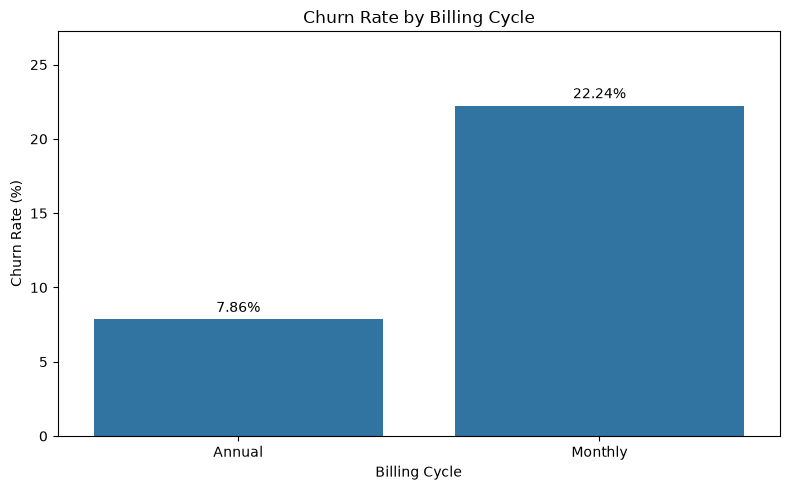

In [15]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=billing_cycle_summary.reset_index(),
    x="billing_cycle",
    y="churn_rate"
)

plt.title("Churn Rate by Billing Cycle")
plt.xlabel("Billing Cycle")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(billing_cycle_summary["churn_rate"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.ylim(0, max(billing_cycle_summary["churn_rate"]) + 5)
plt.tight_layout()

plt.savefig(charts_path / "02_churn_by_billing_cycle.png", dpi=300)
plt.show()

### Business Observation For Chart 2

The churn rate differs substantially by billing cycle. Monthly-billing customers have a churn rate of 22.24%, compared with 7.86% for annual-billing customers. This indicates that billing-cycle type is associated with different observed churn levels and should be considered in further retention analysis.

## Chart 3 — Churn by Tenure Band

For this analysis, we'll use the PRD's four required tenure bands:
- 0–3 months
- 3–12 months
- 1–3 years
- 3+ years

STEP 1: INSPECT THE TENURE DATA

In [16]:
print("Minimum tenure:", customers["tenure_months"].min())
print("Maximum tenure:", customers["tenure_months"].max())
print("Missing tenure values:", customers["tenure_months"].isna().sum())

Minimum tenure: 0
Maximum tenure: 146
Missing tenure values: 0


STEP 2: CREATE THE TENURE BANDS

In [17]:
customers["tenure_band"] = pd.cut(
    customers["tenure_months"],
    bins=[-1, 3, 12, 36, float("inf")],
    labels=["0–3 months", "3–12 months", "1–3 years", "3+ years"]
)

print(customers["tenure_band"].value_counts().sort_index())

tenure_band
0–3 months       749
3–12 months     1446
1–3 years       2836
3+ years       13969
Name: count, dtype: int64


STEP 3: CALCULATE CHURN BY TENURE BAND

In [18]:
tenure_summary = (
    customers
    .groupby("tenure_band", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum())
    )
)

tenure_summary["churn_rate"] = (
    tenure_summary["churned_customers"]
    / tenure_summary["total_customers"]
    * 100
)

tenure_summary

,total_customers,churned_customers,churn_rate
tenure_band,,,
0–3 months,749,561,74.899866
3–12 months,1446,756,52.282158
1–3 years,2836,1026,36.177715
3+ years,13969,1163,8.325578


STEP 4: CREATE CHART 3

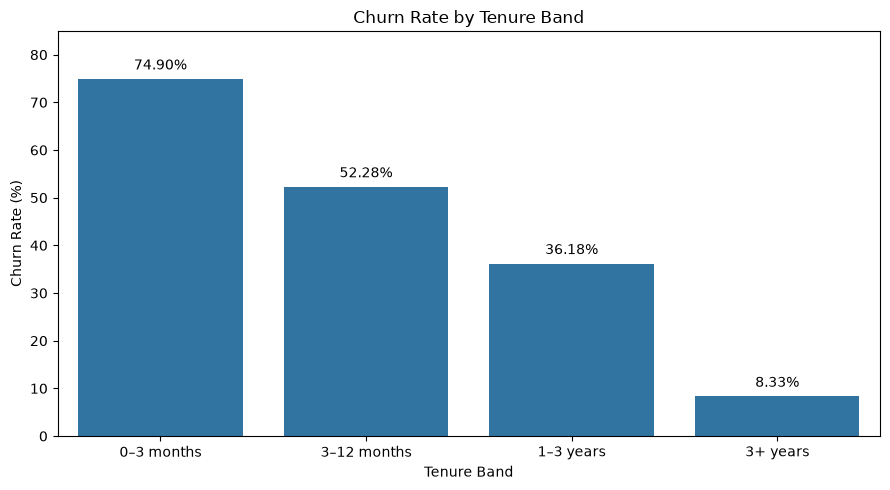

In [19]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_summary.reset_index(),
    x="tenure_band",
    y="churn_rate"
)

plt.title("Churn Rate by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_summary["churn_rate"]):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.ylim(0, max(tenure_summary["churn_rate"]) + 10)
plt.tight_layout()

plt.savefig(charts_path / "03_churn_by_tenure_band.png", dpi=300)
plt.show()

### Business Observation For Chart 3

Churn is highest among customers with shorter tenure. The churn rate is 74.90% for customers with 0–3 months of tenure and 52.28% for those with 3–12 months, compared with 8.33% among customers with 3+ years of tenure. This indicates that early-tenure customers have substantially higher observed churn and may warrant closer retention analysis.

## Chart 4 — Churn by Unresolved Complaints

### For this analysis, we need the complaints table in addition to customers.
### Before calculating anything, let's load the cleaned complaints data and inspect its actual columns.

STEP 1: LOAD THE COMPLAINTS TABLE

In [20]:
complaints = pd.read_csv(cleaned_data_path / "complaints.csv")

print("Complaints:", complaints.shape)

print("\nCOMPLAINTS")
print("-" * 30)
for column in complaints.columns:
    print(column)

Complaints: (16584, 7)

COMPLAINTS
------------------------------
complaint_id
customer_id
complaint_date
complaint_type
severity
status
resolution_date


The relevant columns are:
- customer_id → links complaints to customers
- status → tells us whether the complaint is resolved or unresolved
- resolution_date → provides additional validation context

STEP 2: CHECK COMPLAINT STATUS VALUES

In [21]:
complaints["status"].value_counts(dropna=False)

status
Resolved      9236
Unresolved    7348
Name: count, dtype: int64

FOR THIS EDA, WE NEED TO CLASSIFY EACH CUSTOMER BASED ON WHETHER THEY HAVE AT LEAST ONE UNRESOLVED COMPLAINT. A CUSTOMER WITH MULTIPLE UNRESOLVED COMPLAINTS SHOULD STILL COUNT ONLY ONCE.

STEP 3: IDENTIFY CUSTOMERS WITH UNRESOLVED COMPLAINTS

In [22]:
unresolved_customers = complaints.loc[
    complaints["status"] == "Unresolved",
    "customer_id"
].unique()

print("Customers with unresolved complaints:", len(unresolved_customers))

Customers with unresolved complaints: 6058


STEP 4: CREATE THE UNRESOLVED-COMPLAINT CUSTOMER GROUP

In [23]:
customers["unresolved_complaint"] = customers["customer_id"].isin(
    unresolved_customers
)

print(customers["unresolved_complaint"].value_counts())

unresolved_complaint
False    12942
True      6058
Name: count, dtype: int64


STEP 5: CALCULATE CHURN BY UNRESOLVED COMPLAINT STATUS

In [24]:
complaint_summary = (
    customers
    .groupby("unresolved_complaint")
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum())
    )
)

complaint_summary["churn_rate"] = (
    complaint_summary["churned_customers"]
    / complaint_summary["total_customers"]
    * 100
)

complaint_summary

,total_customers,churned_customers,churn_rate
unresolved_complaint,,,
False,12942,1956,15.113584
True,6058,1550,25.586002


STEP 6: CREATE CHART 4

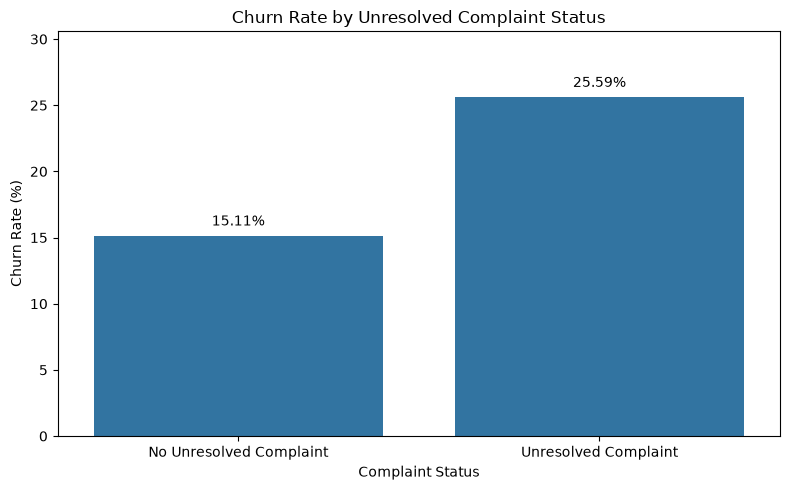

In [25]:
plt.figure(figsize=(8, 5))

plot_data = complaint_summary.reset_index()
plot_data["complaint_group"] = plot_data["unresolved_complaint"].map({
    False: "No Unresolved Complaint",
    True: "Unresolved Complaint"
})

ax = sns.barplot(
    data=plot_data,
    x="complaint_group",
    y="churn_rate"
)

plt.title("Churn Rate by Unresolved Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(plot_data["churn_rate"]):
    plt.text(i, value + 0.8, f"{value:.2f}%", ha="center")

plt.ylim(0, max(plot_data["churn_rate"]) + 5)
plt.tight_layout()

plt.savefig(charts_path / "04_churn_by_unresolved_complaints.png", dpi=300)
plt.show()

### Business Observation For Chart 4

Customers with at least one unresolved complaint have a churn rate of 25.59%, compared with 15.11% for customers without an unresolved complaint. This indicates an association between unresolved complaints and higher observed churn, highlighting complaint resolution as an area for further investigation.

## CHART 5: CHURN BY CUSTOMER SEGMENT

STEP 1: CHECK CUSTOMER SEGMENT VALUES

In [26]:
customers["customer_segment"].value_counts(dropna=False)

customer_segment
Premium       8482
Value         6196
Mass          2932
Enterprise    1390
Name: count, dtype: int64

STEP 2: CALCULATE CHURN BY CUSTOMER SEGMENT

In [27]:
segment_summary = (
    customers
    .groupby("customer_segment")
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum())
    )
)

segment_summary["churn_rate"] = (
    segment_summary["churned_customers"]
    / segment_summary["total_customers"]
    * 100
)

segment_summary

,total_customers,churned_customers,churn_rate
customer_segment,,,
Enterprise,1390,166,11.942446
Mass,2932,782,26.671214
Premium,8482,1283,15.126149
Value,6196,1275,20.577792


STEP 3: CREATE CHART 5

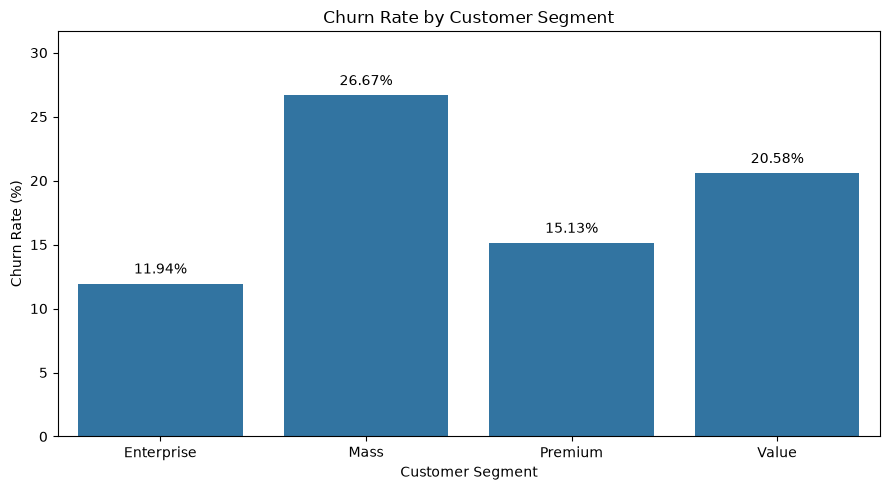

In [28]:
plt.figure(figsize=(9, 5))

plot_data = segment_summary.reset_index()

ax = sns.barplot(
    data=plot_data,
    x="customer_segment",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(plot_data["churn_rate"]):
    plt.text(i, value + 0.8, f"{value:.2f}%", ha="center")

plt.ylim(0, max(plot_data["churn_rate"]) + 5)
plt.tight_layout()

plt.savefig(charts_path / "05_churn_by_customer_segment.png", dpi=300)
plt.show()

### Business Observation For Chart 5

Observed churn varies across customer segments. The Mass segment has a churn rate of 26.67%, followed by Value at 20.58%, Premium at 15.13%, and Enterprise at 11.94%. This indicates differences in observed churn across customer segments and provides a basis for further segment-level retention analysis.

## Chart 6 — Top 10 States/Circles by Churned Customers

STEP 1: INSPECT STATE INFORMATION

In [29]:
print("State ID values:", customers["state_id"].nunique())

print("\nSTATE ID SAMPLE")
print("-" * 30)
print(customers["state_id"].value_counts().head(10))

State ID values: 29

STATE ID SAMPLE
------------------------------
state_id
ST010    1876
ST004    1657
ST016    1501
ST005    1336
ST015    1164
ST011    1130
ST012     981
ST017     861
ST018     832
ST022     817
Name: count, dtype: int64


THERE ARE 29 UNIQUE STATE_ID VALUES, SO WE SHOULD NOT USE THE IDS DIRECTLY IN THE FINAL CHART. WE SHOULD CONNECT THEM TO THE STATES TABLE AND USE THE ACTUAL STATE/CIRCLE NAMES.

STEP 2: LOAD AND INSPECT THE STATES TABLE

In [30]:
states = pd.read_csv(cleaned_data_path / "states.csv")

print("States:", states.shape)

print("\nSTATES")
print("-" * 30)
for column in states.columns:
    print(column)

States: (36, 4)

STATES
------------------------------
state_id
state_name
state_code
zone


THERE ARE 36 STATES IN THE REFERENCE TABLE, WHILE CUSTOMERS CURRENTLY BELONG TO 29 OF THEM. WE'LL ONLY ANALYZE STATES REPRESENTED BY CUSTOMERS.

STEP 3: JOIN STATE NAMES WITH CUSTOMER CHURN STATUS

In [31]:
customer_states = customers[
    ["customer_id", "state_id", "customer_status"]
].merge(
    states[["state_id", "state_name", "state_code"]],
    on="state_id",
    how="left"
)

print(customer_states.head())
print("\nRows:", len(customer_states))
print("Missing state names:", customer_states["state_name"].isna().sum())

  customer_id state_id customer_status    state_name state_code
0    C0000001    ST027         Churned  Chhattisgarh         CG
1    C0000002    ST002          Active       Haryana         HR
2    C0000003    ST011         Churned       Gujarat         GJ
3    C0000004    ST010          Active   Maharashtra         MH
4    C0000005    ST019         Churned     Telangana         TG

Rows: 19000
Missing state names: 0


NOW WE'LL CALCULATE THE NUMBER OF CHURNED CUSTOMERS PER STATE AND SELECT THE TOP 10.

STEP 4: CALCULATE THE TOP 10 STATES BY CHURNED CUSTOMERS

In [32]:
state_churn_summary = (
    customer_states[customer_states["customer_status"] == "Churned"]
    .groupby(["state_name", "state_code"])
    .agg(
        churned_customers=("customer_id", "nunique")
    )
    .sort_values("churned_customers", ascending=False)
    .head(10)
)

state_churn_summary

,,churned_customers
state_name,state_code,
Maharashtra,MH,305
Uttar Pradesh,UP,285
Tamil Nadu,TN,280
Rajasthan,RJ,244
Karnataka,KA,222
Gujarat,GJ,191
Madhya Pradesh,MP,182
Kerala,KL,162
Andhra Pradesh,AP,160


STEP 5: CREATE CHART 6

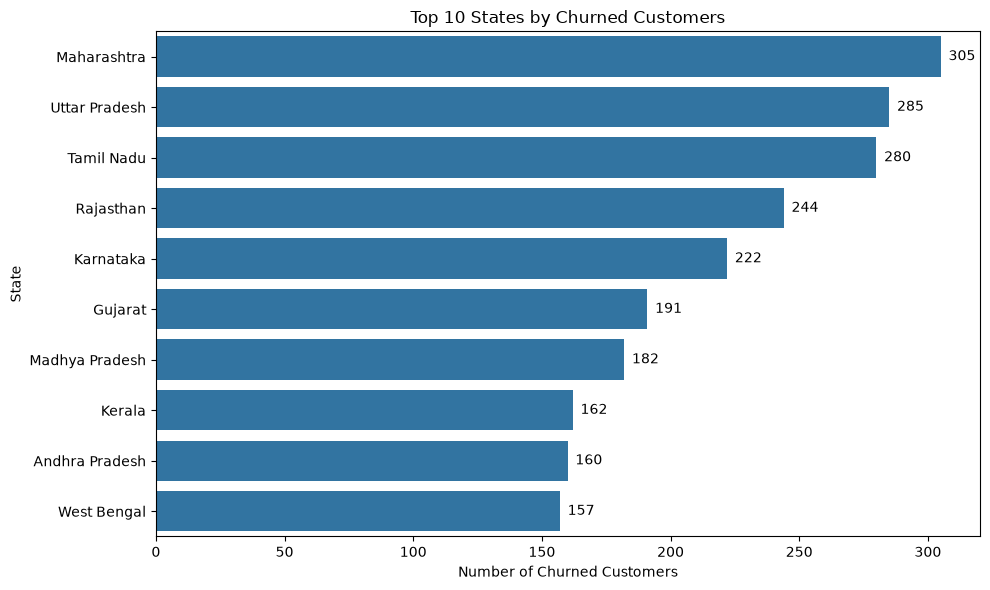

In [33]:
plt.figure(figsize=(10, 6))

plot_data = state_churn_summary.reset_index()

ax = sns.barplot(
    data=plot_data,
    x="churned_customers",
    y="state_name"
)

plt.title("Top 10 States by Churned Customers")
plt.xlabel("Number of Churned Customers")
plt.ylabel("State")

for i, value in enumerate(plot_data["churned_customers"]):
    plt.text(value + 3, i, f"{value:,}", va="center")

plt.tight_layout()

plt.savefig(charts_path / "06_top_10_states_by_churned_customers.png", dpi=300)
plt.show()

### Business Observation For Chart 6

The top 10 states account for a substantial number of churned customers, with Maharashtra, Uttar Pradesh and Tamil Nadu having the highest churned-customer counts in this dataset. These counts reflect the size of the churned customer population in each state and should be interpreted alongside the customer base size of each state.

## Chart 7 — Average Data Usage by City Tier

For this analysis, we need:
- customers → customer_id, city_tier
- usage_data → customer_id, data_gb_used

We'll connect the two tables using customer_id.

STEP 1: LOAD THE USAGE DATA AND INSPECT ITS COLUMNS

In [34]:
usage_data = pd.read_csv(cleaned_data_path / "usage_data.csv")

print("Usage Data:", usage_data.shape)

print("\nUSAGE DATA")
print("-" * 30)
for column in usage_data.columns:
    print(column)

Usage Data: (57000, 5)

USAGE DATA
------------------------------
usage_id
customer_id
usage_month
data_gb_used
data_sessions


STEP 2: CHECK CITY-TIER VALUES

In [35]:
customers["city_tier"].value_counts(dropna=False)

city_tier
Tier-2    9211
Tier-3    4930
Metro     4859
Name: count, dtype: int64

STEP 3: JOIN USAGE DATA WITH CITY TIER

In [36]:
city_usage = usage_data[
    ["customer_id", "data_gb_used"]
].merge(
    customers[["customer_id", "city_tier"]],
    on="customer_id",
    how="left"
)

print(city_usage.head())
print("\nRows:", len(city_usage))
print("Missing city tiers:", city_usage["city_tier"].isna().sum())

  customer_id  data_gb_used city_tier
0    C0000001         22.35    Tier-2
1    C0000001         13.24    Tier-2
2    C0000001         13.09    Tier-2
3    C0000002        167.23     Metro
4    C0000002        109.72     Metro

Rows: 57000
Missing city tiers: 0


STEP 4: CALCULATE AVERAGE DATA USAGE BY CITY TIER

In [37]:
city_tier_usage_summary = (
    city_usage
    .groupby("city_tier")
    .agg(
        average_data_usage_gb=("data_gb_used", "mean")
    )
    .sort_values("average_data_usage_gb", ascending=False)
)

city_tier_usage_summary

,average_data_usage_gb
city_tier,
Metro,36.010909
Tier-2,26.525301
Tier-3,18.375426


STEP 5: CREATE CHART 7

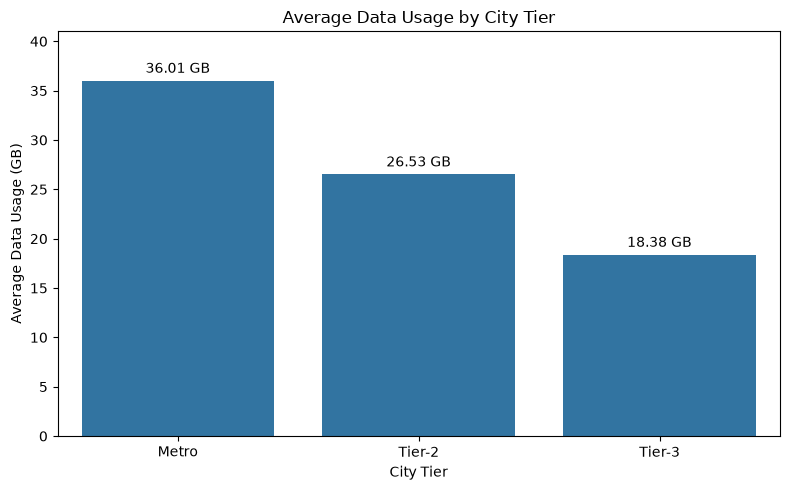

In [38]:
plt.figure(figsize=(8, 5))

plot_data = city_tier_usage_summary.reset_index()

ax = sns.barplot(
    data=plot_data,
    x="city_tier",
    y="average_data_usage_gb"
)

plt.title("Average Data Usage by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Average Data Usage (GB)")

for i, value in enumerate(plot_data["average_data_usage_gb"]):
    plt.text(i, value + 0.8, f"{value:.2f} GB", ha="center")

plt.ylim(0, max(plot_data["average_data_usage_gb"]) + 5)
plt.tight_layout()

plt.savefig(charts_path / "07_average_data_usage_by_city_tier.png", dpi=300)
plt.show()

### Business Observation For Chart 7

Average data usage differs across city tiers in the dataset. Metro customers have the highest average usage at 36.01 GB, followed by Tier-2 customers at 26.53 GB and Tier-3 customers at 18.38 GB. This indicates higher observed data consumption among customers in Metro cities.

## Chart 8 — ARPU Distribution

The PRD specifies ARPU distribution using a histogram of monthly charge.

Since we already established that some customers have multiple subscription records, we'll use the latest subscription record for each customer, just as we did for Chart 2. This prevents customers with multiple historical subscriptions from being counted multiple times.

We already have latest_subscriptions from the earlier analysis.



STEP 1: CHECK THE MONTHLY CHARGE DATA

In [39]:
print("Latest subscription records:", len(latest_subscriptions))
print("Missing monthly charges:", latest_subscriptions["monthly_charge_inr"].isna().sum())

print("\nMonthly charge statistics:")
print(latest_subscriptions["monthly_charge_inr"].describe())

Latest subscription records: 19000
Missing monthly charges: 0

Monthly charge statistics:
count    19000.000000
mean       845.628263
std       1322.819078
min         99.000000
25%        300.000000
50%        499.000000
75%        899.000000
max       8333.000000
Name: monthly_charge_inr, dtype: float64


BECAUSE THE PRD DEFINES THIS ANALYSIS AS AN ARPU DISTRIBUTION USING MONTHLY CHARGE, WE'LL VISUALIZE THE DISTRIBUTION RATHER THAN CALCULATE A SINGLE ARPU VALUE.

STEP 2: CREATE CHART 8- ARPU DISTRIBUTION

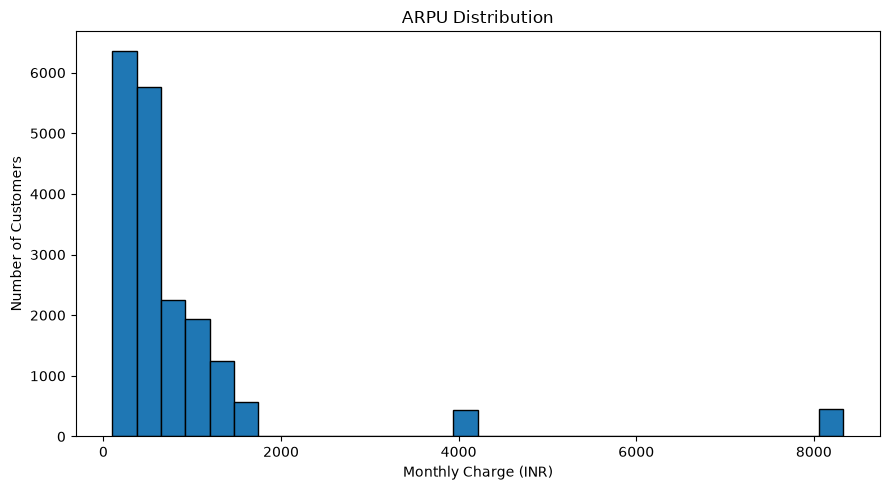

In [40]:
plt.figure(figsize=(9, 5))

plt.hist(
    latest_subscriptions["monthly_charge_inr"],
    bins=30,
    edgecolor="black"
)

plt.title("ARPU Distribution")
plt.xlabel("Monthly Charge (INR)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(charts_path / "08_arpu_distribution.png", dpi=300)
plt.show()

### Business Observation For Chart 8

The monthly charge distribution is concentrated toward lower charge values, with most customers paying below ₹2,000 per month. A smaller number of customers have substantially higher monthly charges, including values around ₹4,000 and ₹8,000+, indicating a right-skewed distribution.

## Chart 9 — Network Quality vs Churn

For this analysis we need the network_quality table.

#### Step 1: Load and inspect network quality data

In [41]:
network_quality = pd.read_csv(
    cleaned_data_path / "network_quality.csv"
)

print("Network Quality:", network_quality.shape)

print("\nNETWORK QUALITY")
print("-" * 30)

for column in network_quality.columns:
    print(column)

Network Quality: (57000, 8)

NETWORK QUALITY
------------------------------
record_id
customer_id
city_id
month
avg_signal_strength_dbm
dropped_call_rate_pct
avg_download_speed_mbps
network_downtime_hours


The network_quality table has the fields we need:
- customer_id → links network records to customers
- avg_signal_strength_dbm → signal quality measure
- dropped_call_rate_pct → call reliability measure
- avg_download_speed_mbps → network speed measure
- network_downtime_hours → network availability measure

Since the PRD says "Network quality vs churn", rather than assuming one metric represents network quality, we'll inspect the distributions of these four measures first. This will let us choose an appropriate measure for the chart based on the actual dataset.

#### Step 2: Inspect network-quality measures

In [42]:
network_quality[
    [
        "avg_signal_strength_dbm",
        "dropped_call_rate_pct",
        "avg_download_speed_mbps",
        "network_downtime_hours"
    ]
].describe()

,avg_signal_strength_dbm,dropped_call_rate_pct,avg_download_speed_mbps,network_downtime_hours
count,57000.000000,57000.000000,57000.000000,57000.000000
mean,-67.992047,2.401331,49.058240,0.717667
std,7.844086,1.291287,22.530991,0.632588
min,-103.300000,0.040000,4.400000,0.000000
25%,-73.300000,1.460000,30.300000,0.270000
50%,-68.000000,2.230000,47.300000,0.540000
75%,-62.600000,3.180000,65.500000,0.980000
max,-50.600000,9.820000,118.700000,6.960000


The four network-quality variables have reasonable ranges and no missing values. Since the PRD specifically asks for “Network quality vs churn”, we need to connect these 57,000 network records to the 19,000 customers and then compare a network-quality measure with churn.

A useful approach here is to use average signal strength because it is a direct measure of network signal quality. NOTE:- dBm values are negative, and a value closer to 0 represents stronger signal.

#### Step 3: Aggregate network quality at customer level

There are 57,000 network records for 19,000 customers, so each customer has multiple network observations. We should calculate each customer's average signal strength first.

In [43]:
customer_network = (
    network_quality
    .groupby("customer_id")
    .agg(
        avg_signal_strength_dbm=("avg_signal_strength_dbm", "mean")
    )
    .reset_index()
)

print(customer_network.head())
print("\nCustomers:", len(customer_network))

  customer_id  avg_signal_strength_dbm
0    C0000001                    -74.3
1    C0000002                    -69.9
2    C0000003                    -62.4
3    C0000004                    -59.2
4    C0000005                    -73.7

Customers: 19000


STEP 4: CONNECT NETWORK QUALITY WITH CHURN STATUS

In [44]:
network_churn = customer_network.merge(
    customers[["customer_id", "customer_status"]],
    on="customer_id",
    how="inner"
)

print(network_churn.head())
print("\nRows:", len(network_churn))
print("\nMissing churn status:", network_churn["customer_status"].isna().sum())

  customer_id  avg_signal_strength_dbm customer_status
0    C0000001                    -74.3         Churned
1    C0000002                    -69.9          Active
2    C0000003                    -62.4         Churned
3    C0000004                    -59.2          Active
4    C0000005                    -73.7         Churned

Rows: 19000

Missing churn status: 0


STEP 5 — CREATE SIGNAL-STRENGTH BANDS

WE'LL DIVIDE CUSTOMERS INTO PRACTICAL SIGNAL-STRENGTH RANGES AND CALCULATE THE CHURN RATE FOR EACH GROUP.

In [45]:
network_churn["signal_band"] = pd.cut(
    network_churn["avg_signal_strength_dbm"],
    bins=[-np.inf, -75, -65, -55, np.inf],
    labels=["Very Weak", "Weak", "Good", "Strong"]
)

print(network_churn["signal_band"].value_counts().sort_index())

signal_band
Very Weak    3597
Weak         8682
Good         5746
Strong        975
Name: count, dtype: int64


STEP 6: CALCULATE CHURN RATE BY SIGNAL QUALITY

In [46]:
signal_churn_summary = (
    network_churn
    .groupby("signal_band", observed=False)
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("customer_status", lambda x: (x == "Churned").sum())
    )
)

signal_churn_summary["churn_rate"] = (
    signal_churn_summary["churned_customers"]
    / signal_churn_summary["total_customers"]
    * 100
)

signal_churn_summary

,total_customers,churned_customers,churn_rate
signal_band,,,
Very Weak,3597,858,23.853211
Weak,8682,1636,18.843584
Good,5746,882,15.349809
Strong,975,130,13.333333


THERE IS A CLEAR PATTERN IN THE ABOVE OUTPUT: CHURN RATE DECREASES AS AVERAGE SIGNAL STRENGTH MOVES FROM WEAKER TO STRONGER BANDS.

STEP 7: CREATE CHART 9

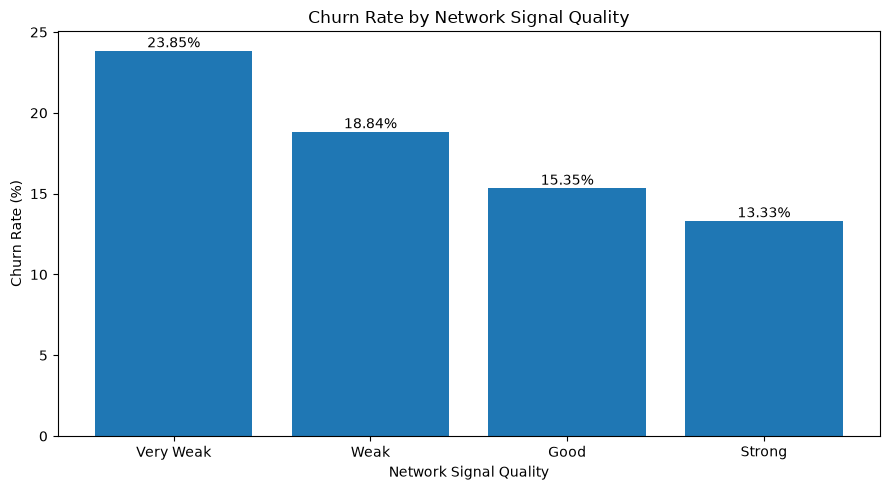

In [49]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    signal_churn_summary.index,
    signal_churn_summary["churn_rate"]
)

plt.title("Churn Rate by Network Signal Quality")
plt.xlabel("Network Signal Quality")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    charts_path / "09_network_quality_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business observation for Chart 9

Churn is higher among customers experiencing weaker network signal quality. The churn rate is 23.85% for the Very Weak signal group compared with 13.33% for the Strong signal group, indicating an association between network signal quality and customer churn in the dataset.

## Chart 10: Retention Campaign Outcomes

#### Step 1: Load the retention campaign data

In [50]:
retention_campaigns = pd.read_csv(
    cleaned_data_path / "retention_campaigns.csv"
)

print("Retention Campaigns:", retention_campaigns.shape)

print("\nRETENTION CAMPAIGNS")
print("-" * 30)

for column in retention_campaigns.columns:
    print(column)

Retention Campaigns: (6475, 8)

RETENTION CAMPAIGNS
------------------------------
campaign_id
customer_id
campaign_name
offer_type
contact_date
channel
response
retained_flag


The important columns are:
- response → whether the customer responded to the campaign
- retained_flag → whether the customer was retained
- customer_id → connects the campaign record to the customer

The PRD specifically asks for retention campaign outcomes: accepted / declined / no response + retained share.

#### Step 2: Inspect campaign outcomes

In [51]:
print("Response values:")
print(retention_campaigns["response"].value_counts(dropna=False))

print("\nRetained flag values:")
print(retention_campaigns["retained_flag"].value_counts(dropna=False))

Response values:
response
Accepted       2982
Declined       1877
No Response    1616
Name: count, dtype: int64

Retained flag values:
retained_flag
Yes    5337
No     1138
Name: count, dtype: int64


Now we need to determine retention outcomes for each response category because the PRD asks for the campaign outcomes plus retained share, so we'll calculate both the number of customers and the retention rate for each response group.

#### Step 3: Calculate retention outcomes by campaign response

In [52]:
retention_summary = (
    retention_campaigns
    .groupby("response")
    .agg(
        total_customers=("customer_id", "nunique"),
        retained_customers=("retained_flag", lambda x: (x == "Yes").sum())
    )
)

retention_summary["retained_share"] = (
    retention_summary["retained_customers"]
    / retention_summary["total_customers"]
    * 100
)

retention_summary

,total_customers,retained_customers,retained_share
response,,,
Accepted,2982,2589,86.820926
Declined,1877,1486,79.168887
No Response,1616,1262,78.094059


STEP 4: CREATE CHART 10

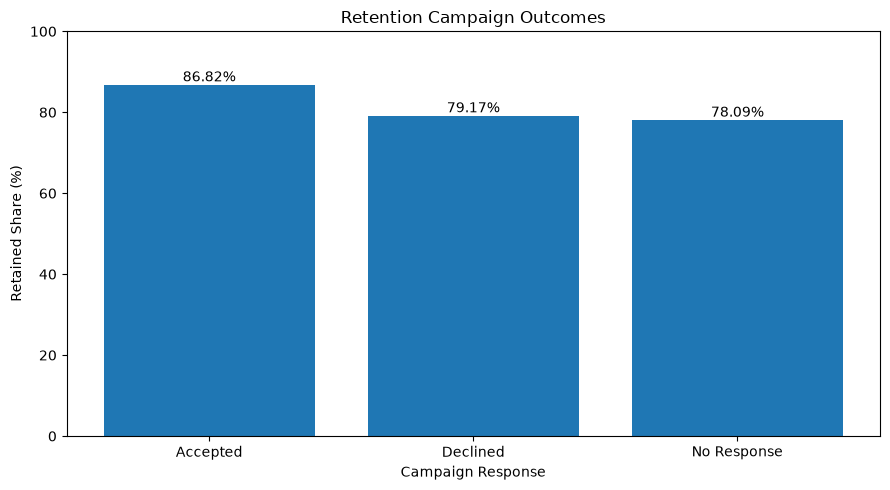

In [55]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    retention_summary.index,
    retention_summary["retained_share"]
)

plt.title("Retention Campaign Outcomes")
plt.xlabel("Campaign Response")
plt.ylabel("Retained Share (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 100)
plt.tight_layout()

plt.savefig(
    charts_path / "10_retention_campaign_outcomes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Observation For Chart 10

Customers who accepted the retention campaign had an 86.82% retained share, compared with 79.17% among those who declined and 78.09% among those who did not respond. In this dataset, the accepted-response group therefore shows a higher observed retention share.

## Phase 2 — Final Output Verification

This section verifies that all 10 required EDA charts have been generated and saved in the project output folder.

In [61]:
expected_charts = [
    "01_overall_churn_rate.png",
    "02_churn_by_billing_cycle.png",
    "03_churn_by_tenure_band.png",
    "04_churn_by_unresolved_complaints.png",
    "05_churn_by_customer_segment.png",
    "06_top_10_states_by_churned_customers.png",
    "07_average_data_usage_by_city_tier.png",
    "08_arpu_distribution.png",
    "09_network_quality_vs_churn.png",
    "10_retention_campaign_outcomes.png"
]

print("Phase 2 Chart Verification")
print("-" * 40)

for chart in expected_charts:
    chart_path = charts_path / chart

    if chart_path.exists():
        print(f"✓ {chart}")
    else:
        print(f"✗ MISSING: {chart}")

Phase 2 Chart Verification
----------------------------------------
✓ 01_overall_churn_rate.png
✓ 02_churn_by_billing_cycle.png
✓ 03_churn_by_tenure_band.png
✓ 04_churn_by_unresolved_complaints.png
✓ 05_churn_by_customer_segment.png
✓ 06_top_10_states_by_churned_customers.png
✓ 07_average_data_usage_by_city_tier.png
✓ 08_arpu_distribution.png
✓ 09_network_quality_vs_churn.png
✓ 10_retention_campaign_outcomes.png
